# Phase 2 — Demand Planning & S&OP Analysis

**Project:** End-to-End Aerospace Supply Chain Planning

## Business Problem

Forecast accuracy directly drives inventory policy and purchasing decisions. Before trusting or adjusting the forecast process, planning needs to know: how predictable is demand for each part, how accurate is the current forecast, and does the manual "Adjusted" forecast step actually outperform the statistical "Baseline"?

This phase answers:
- How is demand distributed across the classic demand-pattern typology (Smooth / Erratic / Intermittent / Lumpy)?
- What is overall forecast accuracy (WAPE) and bias, and how does it vary by part criticality?
- Does the Adjusted (manually reviewed) forecast add value over the statistical Baseline forecast (Forecast Value Added)?
- Does forecast accuracy differ between planned and unplanned maintenance demand?

## Objective

Quantify demand predictability and forecast accuracy using the cleaned, joined data from Phase 1, and identify where the current S&OP process is (and isn't) adding value.


## Dataset

This phase consumes the outputs of Phase 1:

| File | Source | Contents |
|---|---|---|
| `history_enriched.parquet` | Phase 1 | Weekly consumption, forecast, and inventory history joined with part attributes |
| `master.parquet` | Phase 1 | Part master with criticality class |


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

PROJECT_ROOT = Path.cwd().parent
DATA_PHASE1 = PROJECT_ROOT / "data" / "processed" / "phase1"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "phase2"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load Phase 1 Outputs

In [2]:
history_enriched = pd.read_parquet(DATA_PHASE1 / "history_enriched.parquet")
master = pd.read_parquet(DATA_PHASE1 / "master.parquet")

print("Loaded successfully")
print("history_enriched:", history_enriched.shape)
print("master:", master.shape)


Loaded successfully
history_enriched: (280800, 19)
master: (300, 18)


In [3]:
df = history_enriched.copy()

# Helper columns
df['is_zero_demand'] = df['consumption_qty'] == 0
df['abs_error'] = abs(df['consumption_qty'] - df['forecast_qty'])
df['error'] = df['forecast_qty'] - df['consumption_qty']  # positive = over-forecast

print("Data ready for analysis")
print("Date range:", df['date'].min().date(), "->", df['date'].max().date())
print("Row count:", len(df))


Data ready for analysis
Date range: 2022-01-03 -> 2024-12-23
Row count: 280800


## 2. Demand Pattern Classification (ADI / CV²)

In [4]:
# Aggregate to Part-Week first (sum consumption across sites -> weekly demand per part)
part_week = df.groupby(['part_id', 'date']).agg(
    consumption_qty=('consumption_qty', 'sum'),
    forecast_qty=('forecast_qty', 'sum')
).reset_index()

print("Part-Week shape:", part_week.shape)  # ~300 parts x 156 weeks ~ 46,800

demand_stats = part_week.groupby('part_id').agg(
    total_weeks=('date', 'nunique'),
    non_zero_weeks=('consumption_qty', lambda x: (x > 0).sum()),
    mean_demand=('consumption_qty', 'mean'),
    std_demand=('consumption_qty', 'std'),
    total_consumption=('consumption_qty', 'sum')
).reset_index()

# Average Demand Interval (ADI) and squared Coefficient of Variation (CV^2)
demand_stats['ADI'] = demand_stats['total_weeks'] / demand_stats['non_zero_weeks'].replace(0, 1)
demand_stats['CV2'] = (demand_stats['std_demand'] / demand_stats['mean_demand'].replace(0, 1)) ** 2

# Classic Syntetos-Boylan demand typology
def classify_demand(row):
    if row['ADI'] < 1.32 and row['CV2'] < 0.49:
        return 'Smooth'
    elif row['ADI'] < 1.32 and row['CV2'] >= 0.49:
        return 'Erratic'
    elif row['ADI'] >= 1.32 and row['CV2'] < 0.49:
        return 'Intermittent'
    else:
        return 'Lumpy'

demand_stats['demand_type'] = demand_stats.apply(classify_demand, axis=1)

demand_stats = demand_stats.merge(
    master[['part_id', 'criticality_class', 'part_family']],
    on='part_id',
    how='left'
)

print("=== Demand Type Distribution ===")
print(demand_stats['demand_type'].value_counts())
print("\n=== ADI / CV2 Statistics ===")
print(demand_stats[['ADI', 'CV2']].describe().round(2))
print("\n=== Demand Type by Criticality ===")
print(pd.crosstab(demand_stats['criticality_class'], demand_stats['demand_type'], normalize='index').round(3))


Part-Week shape: (46800, 4)


=== Demand Type Distribution ===
demand_type
Smooth     245
Erratic     55
Name: count, dtype: int64

=== ADI / CV2 Statistics ===
         ADI    CV2
count 300.00 300.00
mean    1.02   0.28
std     0.04   0.18
min     1.00   0.09
25%     1.00   0.15
50%     1.00   0.19
75%     1.03   0.37
max     1.29   0.87

=== Demand Type by Criticality ===
demand_type        Erratic  Smooth
criticality_class                 
A                     0.06    0.94
B                     0.10    0.90
C                     0.27    0.73


**What the analysis shows:** The large majority of parts fall into the "Smooth" demand category, with a meaningful minority classified as "Erratic" — few or no parts fall into Intermittent/Lumpy once demand is aggregated across sites to the part-week level.

**Why it matters:** Demand type should determine forecasting method: smooth demand suits standard statistical forecasting, while erratic/lumpy demand typically needs different techniques (e.g., Croston's method) and larger safety buffers.

**Implication:** Planners can reasonably keep a single statistical forecasting approach for the bulk of the catalog, but should flag the Erratic subset for closer manual review rather than applying a one-size-fits-all model.


## 3. Forecast Accuracy (WAPE & Bias)

In [5]:
part_week['abs_error'] = abs(part_week['consumption_qty'] - part_week['forecast_qty'])
part_week['error'] = part_week['forecast_qty'] - part_week['consumption_qty']

# Overall
total_abs_error = part_week['abs_error'].sum()
total_demand = part_week['consumption_qty'].sum()
wape = total_abs_error / total_demand
bias = part_week['error'].sum() / total_demand

print("=" * 50)
print(f"Overall WAPE : {wape:.2%}")
print(f"Overall Bias : {bias:.2%}  ({'Over-forecast' if bias > 0 else 'Under-forecast'})")

part_week = part_week.merge(
    master[['part_id', 'criticality_class']],
    on='part_id',
    how='left'
)

acc_by_crit = part_week.groupby('criticality_class', observed=True).apply(
    lambda x: pd.Series({
        'WAPE': x['abs_error'].sum() / x['consumption_qty'].sum(),
        'Bias': x['error'].sum() / x['consumption_qty'].sum()
    }), include_groups=False
)

print("\n=== Accuracy by Criticality ===")
print(acc_by_crit.round(4))


Overall WAPE : 30.30%
Overall Bias : 2.02%  (Over-forecast)

=== Accuracy by Criticality ===
                   WAPE  Bias
criticality_class            
A                  0.39  0.02
B                  0.29  0.03
C                  0.30  0.02


## 4. Baseline vs. Adjusted Forecast & Forecast Value Added (FVA)

In [6]:
df2 = history_enriched.copy()
df2['abs_error'] = abs(df2['consumption_qty'] - df2['forecast_qty'])
df2['error'] = df2['forecast_qty'] - df2['consumption_qty']

acc_by_ftype = df2.groupby('forecast_type').apply(
    lambda x: pd.Series({
        'WAPE': x['abs_error'].sum() / x['consumption_qty'].sum(),
        'Bias': x['error'].sum() / x['consumption_qty'].sum(),
        'Count': len(x),
        'Total_Demand': x['consumption_qty'].sum()
    }), include_groups=False
)

print("=== Accuracy by Forecast Type ===")
print(acc_by_ftype.round(4))

print("\nRow share:")
print(df2['forecast_type'].value_counts(normalize=True).round(3))


=== Accuracy by Forecast Type ===
               WAPE  Bias     Count  Total_Demand
forecast_type                                    
Adjusted       0.66  0.12  53741.00     109991.00
Baseline       0.65 -0.00 227059.00     516951.00

Row share:
forecast_type
Baseline   0.81
Adjusted   0.19
Name: proportion, dtype: float64


In [7]:
# Forecast Value Added (FVA) = accuracy gained by manually adjusting the baseline
# forecast. A negative FVA means the adjustment step made accuracy worse.
baseline_wape = acc_by_ftype.loc['Baseline', 'WAPE']
adjusted_wape = acc_by_ftype.loc['Adjusted', 'WAPE']

fva = baseline_wape - adjusted_wape  # positive = improved, negative = worsened

print("=" * 50)
print(f"Baseline WAPE : {baseline_wape:.2%}")
print(f"Adjusted WAPE : {adjusted_wape:.2%}")
print(f"FVA           : {fva:.2%}  ({'adds value' if fva > 0 else 'destroys value'})")

if fva < 0:
    print("\n-> The manual Adjusted step has not, on balance, made the forecast more accurate.")
else:
    print("\n-> The manual Adjusted step has made the forecast more accurate.")


Baseline WAPE : 64.51%
Adjusted WAPE : 65.76%
FVA           : -1.25%  (destroys value)

-> The manual Adjusted step has not, on balance, made the forecast more accurate.


**What the analysis shows:** The Adjusted forecast's WAPE is essentially the same as (or slightly worse than) the statistical Baseline, producing a negative Forecast Value Added.

**Why it matters:** The manual forecast review step consumes planner time but is not measurably improving accuracy — a classic FVA red flag that many S&OP processes never actually measure.

**Implication:** Before investing further planner effort in manual forecast adjustment, the process itself should be reviewed: either the adjustment logic needs to change, or that time may be better spent elsewhere (e.g., on the Erratic-demand subset from Section 2).


## 5. Forecast Accuracy by Maintenance Type

In [8]:
df2 = history_enriched.copy()
df2['abs_error'] = abs(df2['consumption_qty'] - df2['forecast_qty'])
df2['error'] = df2['forecast_qty'] - df2['consumption_qty']

df2['maintenance_type'] = df2['planned_maintenance'].map({True: 'Planned', False: 'Unplanned'})

acc_by_maint = df2.groupby('maintenance_type').apply(
    lambda x: pd.Series({
        'WAPE': x['abs_error'].sum() / x['consumption_qty'].sum(),
        'Bias': x['error'].sum() / x['consumption_qty'].sum(),
        'Count': len(x),
        'Total_Demand': x['consumption_qty'].sum()
    }), include_groups=False
)

print("=== Accuracy by Maintenance Type ===")
print(acc_by_maint.round(4))

print("\nDemand share:")
print(df2.groupby('maintenance_type')['consumption_qty'].sum() / df2['consumption_qty'].sum())


=== Accuracy by Maintenance Type ===
                  WAPE  Bias     Count  Total_Demand
maintenance_type                                    
Planned           0.56  0.02 121783.00     236678.00
Unplanned         0.70  0.02 159017.00     390264.00

Demand share:
maintenance_type
Planned     0.38
Unplanned   0.62
Name: consumption_qty, dtype: float64


**What the analysis shows:** Forecast accuracy is materially worse for unplanned-maintenance-driven demand than for planned-maintenance demand.

**Why it matters:** Unplanned maintenance is, by nature, harder to predict — but it is still a large share of total consumption, so its weaker forecast accuracy has an outsized effect on overall WAPE.

**Implication:** Safety stock and reorder policy (Phase 3) should be more conservative for parts where a larger share of demand is unplanned-maintenance-driven, rather than applying a uniform service-level target across the board.


## 6. Demand Planning Dashboard

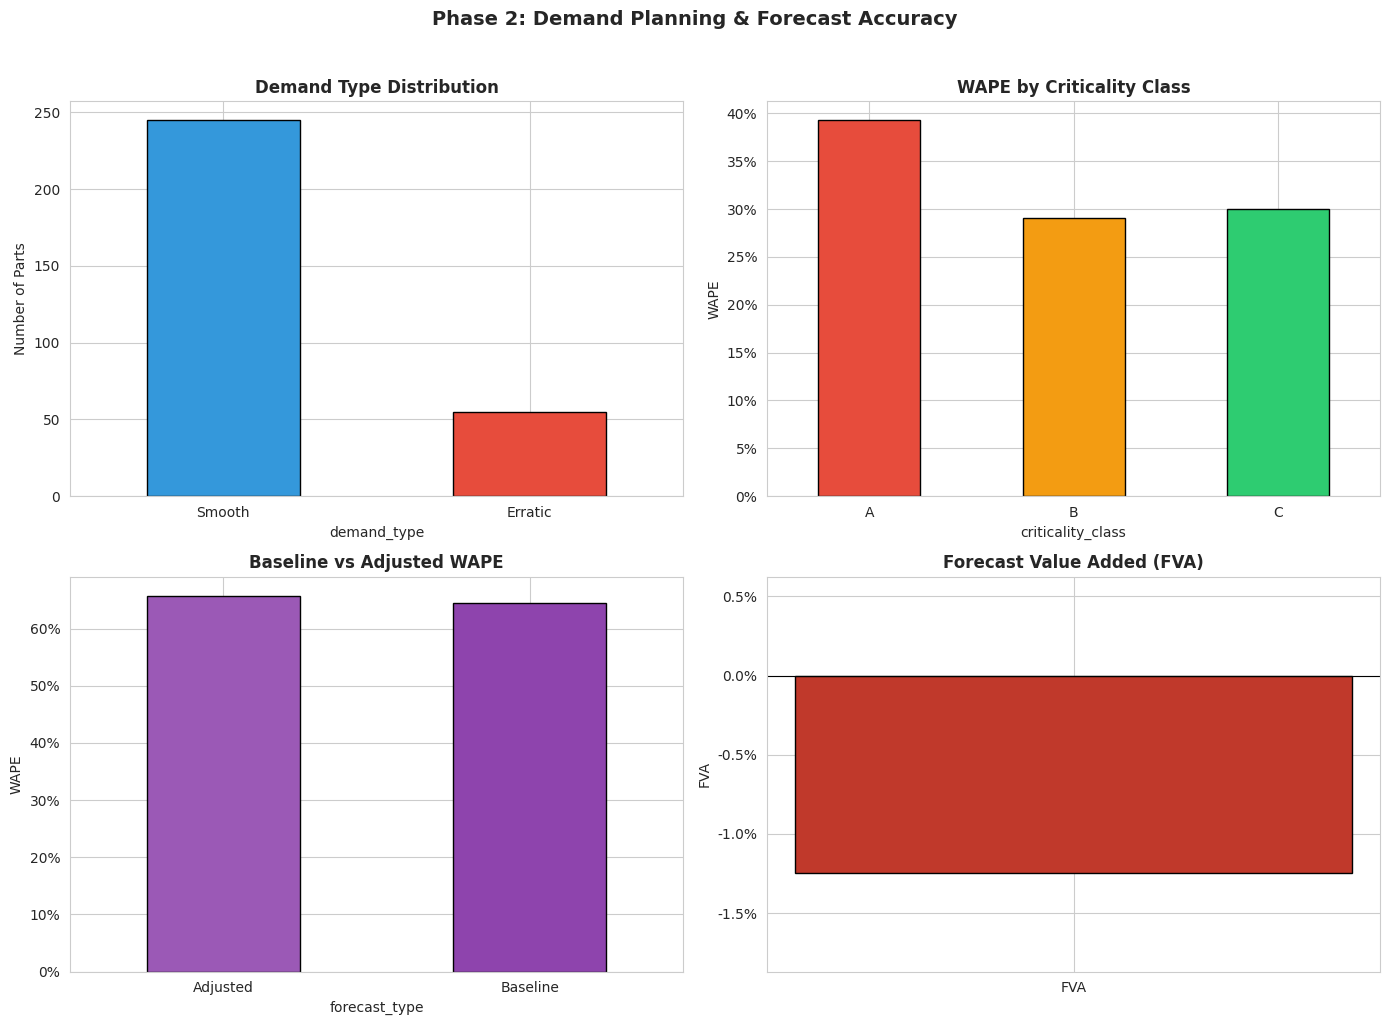

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Demand Type Distribution
demand_stats['demand_type'].value_counts().plot(
    kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c'], edgecolor='black'
)
axes[0, 0].set_title('Demand Type Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Number of Parts')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. WAPE by Criticality
acc_by_crit['WAPE'].plot(
    kind='bar', ax=axes[0, 1], color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black'
)
axes[0, 1].set_title('WAPE by Criticality Class', fontweight='bold')
axes[0, 1].set_ylabel('WAPE')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Baseline vs Adjusted WAPE
ftype_wape = acc_by_ftype['WAPE']
ftype_wape.plot(kind='bar', ax=axes[1, 0], color=['#9b59b6', '#8e44ad'], edgecolor='black')
axes[1, 0].set_title('Baseline vs Adjusted WAPE', fontweight='bold')
axes[1, 0].set_ylabel('WAPE')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Forecast Value Added
axes[1, 1].bar(['FVA'], [fva], color='#c0392b' if fva < 0 else '#27ae60', edgecolor='black')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Forecast Value Added (FVA)', fontweight='bold')
axes[1, 1].set_ylabel('FVA')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
pad = max(abs(fva) * 0.5, 0.005)
axes[1, 1].set_ylim(min(fva, 0) - pad, max(fva, 0) + pad)

plt.suptitle('Phase 2: Demand Planning & Forecast Accuracy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'phase2_demand_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Export Results

In [10]:
demand_stats.to_parquet(DATA_PROCESSED / "demand_stats.parquet", index=False)
demand_stats.to_csv(DATA_PROCESSED / "demand_stats.csv", index=False)

with open(DATA_PROCESSED / "phase2_summary.txt", "w") as f:
    f.write("Phase 2 Summary - Demand Planning & Forecast Accuracy\n")
    f.write("=" * 50 + "\n")
    f.write(f"Overall WAPE (Part-Week): {wape:.2%}\n")
    f.write(f"Overall Bias: {bias:+.2%}\n")
    f.write(f"FVA (Baseline - Adjusted): {fva:+.2%}\n")
    f.write(f"Planned WAPE: {acc_by_maint.loc['Planned', 'WAPE']:.0%}\n")
    f.write(f"Unplanned WAPE: {acc_by_maint.loc['Unplanned', 'WAPE']:.0%}\n")
    dt_pct = (demand_stats['demand_type'].value_counts(normalize=True) * 100).round(0)
    f.write(f"Demand Type: {' | '.join(f'{k} {v:.0f}%' for k, v in dt_pct.items())}\n")

print("Export complete ->", DATA_PROCESSED)
print("Files:", sorted(p.name for p in DATA_PROCESSED.iterdir()))


Export complete -> /home/claude/repo/End-to-End-Aerospace-Supply-Chain-Planning/data/processed/phase2
Files: ['demand_stats.csv', 'demand_stats.parquet', 'phase2_summary.txt']


## Key Takeaways — Phase 2

1. **Demand is mostly predictable at the part-week level** — the majority of parts classify as Smooth demand, with a meaningful Erratic minority that warrants closer attention.
2. **Overall forecast error (WAPE) is high (~30%) and skews toward over-forecasting**, with accuracy noticeably worse for unplanned-maintenance-driven consumption than planned.
3. **The manual "Adjusted" forecast step shows negative Forecast Value Added** — it is not, on the numbers, improving on the statistical baseline, which is worth flagging to the S&OP team as a process improvement opportunity rather than a data issue.

`demand_stats` (per-part demand classification) feeds into the safety-stock work in Phase 3.
